In [ ]:
# [auto] project-root setup
import os, sys
from pathlib import Path

# 自动向上查找项目根目录 (含 .gitignore 的文件夹)
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / '.gitignore').exists():
    _p = _p.parent
PROJECT_ROOT = _p

# 切换 cwd 到项目根, 使所有相对路径 (Stage1_Exploration/, Refined_Results_v4/ 等) 保持有效
os.chdir(PROJECT_ROOT)
# 让 notebooks 能 `from viz_config import VizConfig`
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
print(f'[setup] PROJECT_ROOT = {PROJECT_ROOT}')


正在读取数据...
正在进行非线性最小二乘拟合...

拟合成功！最优参数如下：
alpha (a) = 0.081743
beta  (b) = 0.642252
gamma (c) = 27.985516
delta (d) = 1.090192
正在绘制 1.pdf (衰减曲线对比)...
正在绘制 2.pdf (预测对比图)...

任务完成！
拟合结果已成功保存。


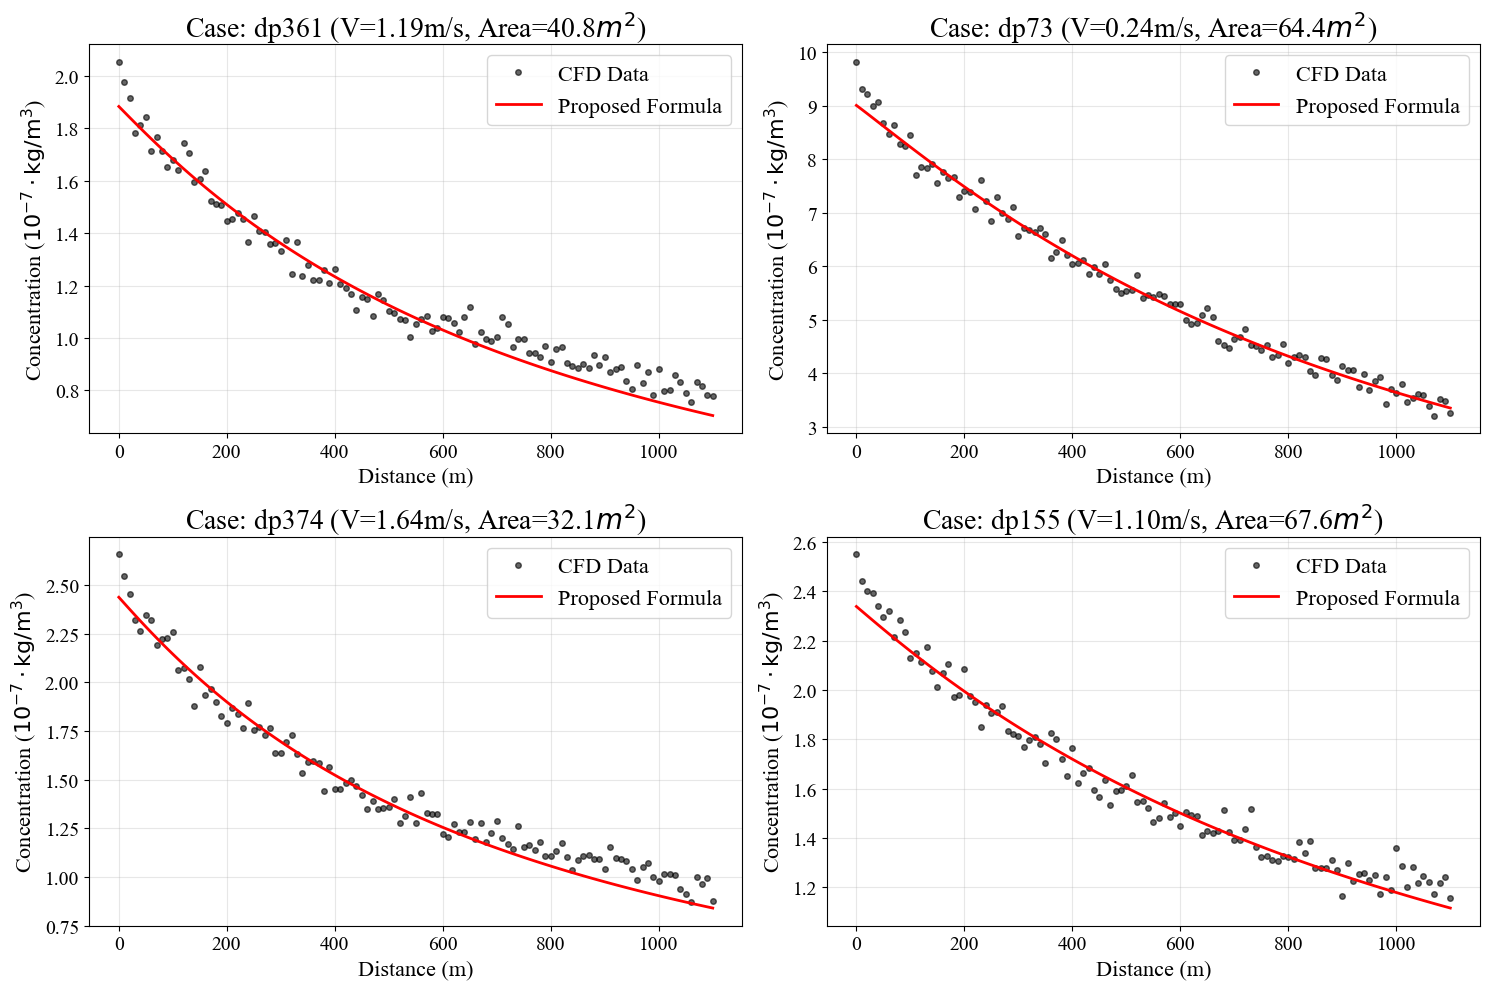

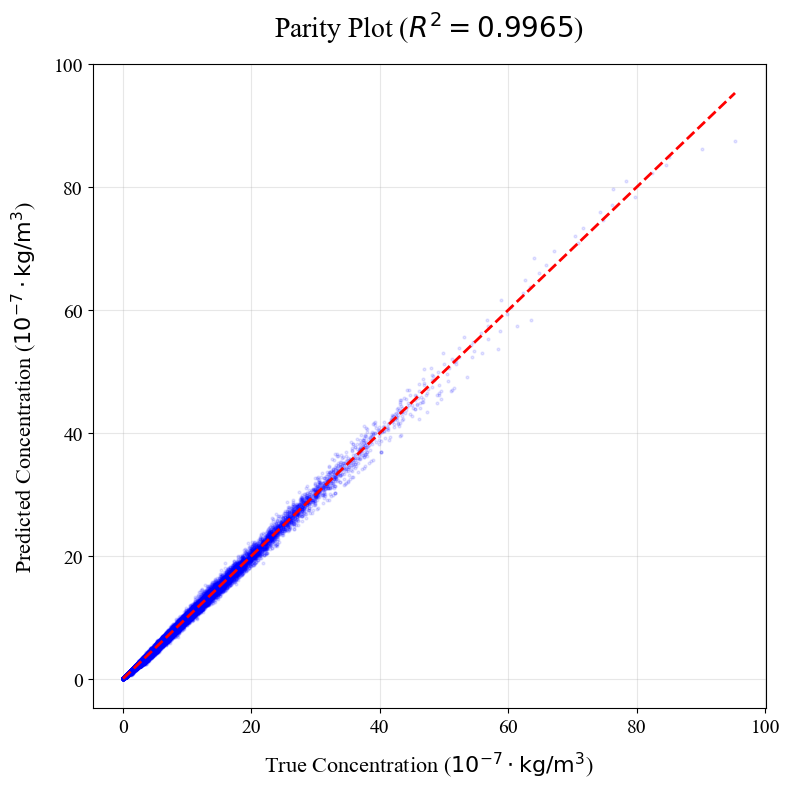

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from viz_config import VizConfig

# ==========================================
# 0. 配置与初始化 (Configuration & Initialization)
# ==========================================
# 引入统一的绘图风格配置 (viz_config.py)，确保本阶段生成的验证图风格一致
VizConfig.set_style()

OUTPUT_DIR = "Stage2_Hypothesis_Verification"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 浓度缩放系数 (Scaling Factor)
# 将 1e-7 量级的浓度数据放大到 1.0 量级，避免非线性拟合时的数值稳定性问题
SCALE = 1e7

# ==========================================
# 1. 准备数据 (Data Preparation)
# ==========================================
print("正在读取数据...")
if not os.path.exists('data/train_dataset_ready.csv'):
    print("错误：未找到 train_dataset_ready.csv 文件")
else:
    df = pd.read_csv('data/train_dataset_ready.csv')

    # 对浓度进行缩放处理
    df['C_in_scaled'] = df['C_in'] * SCALE
    df['C_out_scaled'] = df['C_out'] * SCALE

    # 提取特征变量用于后续拟合
    V_in = df['V_in'].values
    Area = df['Area'].values
    Dist = df['Distance'].values
    C_in_scaled = df['C_in_scaled'].values
    C_out_scaled = df['C_out_scaled'].values

    # ==========================================
    # 2. 定义假设公式 (Hypothesis Formula Definition)
    # ==========================================
    # 该公式结构是基于 Stage 1 (PySR) 的探索结果和物理直觉提炼而成的
    # 形式：C = C_in / [ (a * x) / (S - b * sqrt(x/v) + c) + d ]
    def hypothesis_formula(X, a, b, c, d):
        v, area, dist, c_in = X
        
        # 物理量纲项：dist/v 具有时间的量纲 (Time Scale)
        # 1e-6 用于防止除零错误
        time_scale = np.sqrt(dist / (v + 1e-6))
        
        # 有效面积项 (Effective Area Term)
        # 分母中的核心项，反映了随时间和距离扩散后的等效影响面积
        # np.maximum 确保该项不为负，维持物理意义
        effective_term = area - b * time_scale + c
        
        # 构造完整的分母
        denominator = (a * dist) / (np.maximum(effective_term, 0.1)) + d
        
        return c_in / denominator

    # ==========================================
    # 3. 执行参数拟合 (Parameter Fitting)
    # ==========================================
    print("正在进行非线性最小二乘拟合...")
    
    # 初始猜测值 (Initial Guess)
    # 这些值来源于 Stage 1 的符号回归初步结果，作为优化的起点
    # a(alpha)≈0.08, b(beta)≈0.6, c(gamma)≈26, d(delta)≈1.0
    p0 = [0.08, 0.6, 26.0, 1.0] 
    X_data = (V_in, Area, Dist, C_in_scaled)

    try:
        # 使用 scipy.optimize.curve_fit 进行拟合
        # bounds 限制了参数的搜索空间，确保参数具有合理的物理符号 (如全部为正)
        popt, pcov = curve_fit(
            hypothesis_formula, 
            X_data, 
            C_out_scaled, 
            p0=p0, 
            maxfev=20000,
            bounds=([0, 0, 0, 0.5], [2.0, 10.0, 100.0, 2.0])
        )
        
        a_opt, b_opt, c_opt, d_opt = popt
        
        # 使用优化后的参数计算预测值
        y_pred = hypothesis_formula(X_data, *popt)
        
        print("\n" + "="*40)
        print("拟合成功！最优参数如下：")
        print(f"alpha (a) = {a_opt:.6f}")
        print(f"beta  (b) = {b_opt:.6f}")
        print(f"gamma (c) = {c_opt:.6f}")
        print(f"delta (d) = {d_opt:.6f}")

        # 计算评估指标 (R2 和 RMSE)
        r2 = r2_score(C_out_scaled, y_pred)
        rmse = np.sqrt(mean_squared_error(C_out_scaled, y_pred))
        
        # 保存最终参数结果到文本文件
        with open(os.path.join(OUTPUT_DIR, "final_parameters.txt"), "w") as f:
            f.write(f"R2 Score: {r2:.6f}\nRMSE: {rmse:.6f}\n")
            f.write(f"alpha: {a_opt}\nbeta: {b_opt}\ngamma: {c_opt}\ndelta: {d_opt}\n")

        # ==========================================
        # 4. 可视化验证 1: 衰减曲线 (Curve Validation)
        # ==========================================
        print("正在绘制 1.pdf (衰减曲线对比)...")
        unique_cases = df['Case'].unique()
        np.random.seed(42) 
        # 随机抽取 4 个 Case 进行展示
        sample_cases = np.random.choice(unique_cases, 4, replace=False)
        
        # 定义局部字号 (也可直接使用 VizConfig)
        CASE_TITLE_SIZE = VizConfig.TITLE_SIZE
        CASE_LABEL_SIZE = VizConfig.LABEL_SIZE
        CASE_TICK_SIZE = VizConfig.TICK_SIZE
        CASE_LEGEND_SIZE = VizConfig.LEGEND_SIZE
        
        fig1 = plt.figure(figsize=(15, 10))
        unit_c = r"($10^{-7} \cdot \text{kg/m}^3$)"
        
        for i, case_id in enumerate(sample_cases):
            # 提取当前 Case 数据
            case_data = df[df['Case'] == case_id].sort_values('Distance')
            dist_case = case_data['Distance'].values
            c_true_case = case_data['C_out_scaled'].values
            v_case = case_data['V_in'].values
            a_case = case_data['Area'].values
            c_in_case = case_data['C_in_scaled'].values
            
            # 使用拟合参数生成预测曲线
            pred_case = hypothesis_formula((v_case, a_case, dist_case, c_in_case), *popt)
            
            ax = plt.subplot(2, 2, i+1)
            # 绘制真实值散点 (CFD Data)
            ax.plot(dist_case, c_true_case, 'o', color=VizConfig.COLOR_AXIS, markersize=4, 
                    alpha=0.6, label='CFD Data', rasterized=True)
            # 绘制预测曲线 (Proposed Formula) - 红色高亮
            ax.plot(dist_case, pred_case, color=VizConfig.COLOR_HIGHLIGHT, linewidth=2, label='Proposed Formula')
            
            ax.set_title(f"Case: {case_id} (V={v_case[0]:.2f}m/s, Area={a_case[0]:.1f}$m^2$)", 
                         fontsize=CASE_TITLE_SIZE)
            ax.set_xlabel("Distance (m)", fontsize=CASE_LABEL_SIZE)
            ax.set_ylabel(f"Concentration {unit_c}", fontsize=CASE_LABEL_SIZE)
            
            ax.tick_params(axis='both', labelsize=CASE_TICK_SIZE)
            ax.legend(fontsize=CASE_LEGEND_SIZE)
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "1.pdf"), dpi=VizConfig.DPI)
        
        # ==========================================
        # 5. 可视化验证 2: 预测对比图 (Parity Plot)
        # ==========================================
        print("正在绘制 2.pdf (预测对比图)...")
        
        plt.figure(figsize=(8, 8))
        # 绘制所有样本点的预测值 vs 真实值
        plt.plot(C_out_scaled, y_pred, 'o', color=VizConfig.COLOR_MAIN, markersize=2, 
                 alpha=0.1, rasterized=True)
        
        # 绘制 1:1 参考线 (完美预测线)
        plt.plot([C_out_scaled.min(), C_out_scaled.max()], 
                 [C_out_scaled.min(), C_out_scaled.max()], 
                 color=VizConfig.COLOR_HIGHLIGHT, linestyle='--', linewidth=2)
        
        plt.xlabel(f"True Concentration {unit_c}", fontsize=VizConfig.LABEL_SIZE, labelpad=10)
        plt.ylabel(f"Predicted Concentration {unit_c}", fontsize=VizConfig.LABEL_SIZE, labelpad=10)
        plt.title(f"Parity Plot ($R^2={r2:.4f}$)", fontsize=VizConfig.TITLE_SIZE, pad=20)
        
        plt.xticks(fontsize=VizConfig.TICK_SIZE)
        plt.yticks(fontsize=VizConfig.TICK_SIZE)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "2.pdf"), dpi=VizConfig.DPI)

        print(f"\n任务完成！")
        print(f"拟合结果已成功保存。")

    except Exception as e:
        print(f"拟合过程中出现错误: {e}")
        import traceback
        traceback.print_exc()